# BERT Fine-Tuning ile Duygu Sınıflandırması (Sentiment Analysis)

Bu notebook'ta HuggingFace üzerinde Türkçe için önceden eğitilmiş (pre-trained) olan `dbmdz/electra-base-turkish-cased-discriminator` BERT modelini alıp, **kendi veri setimiz üzerinde yeniden eğiteceğiz (Fine-Tuning)**.

Önceki notebook'ta aynı modeli hiç eğitmeden (Zero-Shot / Inference) kullanmış ve **%71** civarı bir başarı elde etmiştik. Bu notebook'ta modeli kendi verilerimize özelleştirerek bu başarı oranını önemli ölçüde artırmayı hedefliyoruz.

### Kullanılan Teknikler
| Teknik | Açıklama |
|---|---|
| **Transfer Learning** | Büyük veri setinde önceden eğitilmiş modeli kendi verimize uyarlıyoruz |
| **Fine-Tuning** | Modelin tüm katmanlarını kendi verimizle yeniden eğitiyoruz |
| **HuggingFace Trainer API** | Eğitim döngüsünü, değerlendirmeyi ve checkpoint yönetimini otomatikleştiriyoruz |
| **GPU Hızlandırma (CUDA)** | RTX 3060 GPU ile eğitimi hızlandırıyoruz |
| **Undersampling** | Sınıf dengesizliğini gidermek için her sınıftan eşit örnek alıyoruz |
| **Stratified Split** | Eğitim/test bölümünde sınıf oranlarını koruyoruz |

### Notebook Yapısı
1. Ortam Kurulumu
2. Model ve Tokenizer Yükleme
3. Veri Setinin Hazırlanması
4. Tokenizasyon
5. Eğitim Parametreleri
6. Model Eğitimi (Fine-Tuning)
7. Eğitim Sürecinin Görselleştirilmesi
8. Test Seti Değerlendirmesi
9. Örnek Tahminler İncelemesi
10. Güven Skoru Analizi
11. Attention (Dikkat) Haritası Görselleştirmesi
12. Zero-Shot vs Fine-Tuned Karşılaştırma
13. Sonuçların Dışa Aktarılması


## Bölüm 1 — Ortam Kurulumu
- GPU/CPU kontrolü ve bellek bilgisi
- Gerekli kütüphanelerin yüklenmesi
- Tekrarlanabilirlik için rastgele sayı üreteci (seed) sabitleme


In [7]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import json
import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import display, HTML

import optuna
from transformers import (
    EarlyStoppingCallback,
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_fscore_support, 
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

# Tekrarlanabilirlik için seed sabitleme
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# GPU Kontrolü
device = "cuda" if torch.cuda.is_available() else "cpu"
print("=" * 60)
print("  ORTAM BİLGİLERİ")
print("=" * 60)
print(f"  PyTorch Sürümü:  {torch.__version__}")
print(f"  CUDA Kullanılabilir: {torch.cuda.is_available()}")
if device == "cuda":
    print(f"  GPU Adı:         {torch.cuda.get_device_name(0)}")
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"  GPU Belleği:     {gpu_mem:.1f} GB")
    print(f"  CUDA Sürümü:     {torch.version.cuda}")
print(f"  Kullanılan Cihaz: {device.upper()}")
print("=" * 60)

# Görselleştirme ayarları
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")


  ORTAM BİLGİLERİ
  PyTorch Sürümü:  2.6.0+cu124
  CUDA Kullanılabilir: True
  GPU Adı:         NVIDIA GeForce RTX 3060 Laptop GPU
  GPU Belleği:     6.0 GB
  CUDA Sürümü:     12.4
  Kullanılan Cihaz: CUDA


## Bölüm 2 — Model ve Tokenizer Yükleme

**Model:** `dbmdz/electra-base-turkish-cased-discriminator`  
Bu model, BERT mimarisi üzerine Türkçe metinlerle önceden eğitilmiş bir Transformer modelidir. Orijinal hali 2 sınıflı (positive/negative) olup, biz bunu **3 sınıfa** (positive/negative/neutral) uyarlıyoruz.

**Uyarlama Stratejisi:**  
`ignore_mismatched_sizes=True` parametresi ile modelin son sınıflandırma katmanı (classifier head) yeniden başlatılır. Bu, modelin dil anlama katmanlarını (BERT gövdesi) korurken, çıkış katmanını yeni sınıf yapımıza göre sıfırdan öğrenmesini sağlar.

**Tokenizer:**  
Metinleri modelin anlayabileceği token dizilerine (input_ids, attention_mask) dönüştürür.


In [8]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from huggingface_hub import login

# Hugging Face limitlerine takılmamak için token'ınız ile giriş yapılıyor
login(token="<YOUR_HUGGINGFACE_TOKEN>")

# Cihaz ayarı (Ekran kartı varsa onu, yoksa işlemciyi kullanır)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "dbmdz/electra-base-turkish-cased-discriminator"

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Etiket haritaları
id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}

# Modeli 3 sınıflı olarak yükleme (Kırmızı "num_labels=3" uyarısını gizler)
config = AutoConfig.from_pretrained(model_name)
config.num_labels = 3
config.id2label = id2label
config.label2id = label2id

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    config=config,
    ignore_mismatched_sizes=True
)

# Model özet bilgileri
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("  MODEL BİLGİLERİ")
print("=" * 60)
print(f"  Model:             {model_name}")
print(f"  Sınıf Sayısı:      {model.config.num_labels}")
print(f"  Etiketler:         {id2label}")
print(f"  Toplam Parametre:  {total_params:,}")
print(f"  Eğitilebilir:      {trainable_params:,}")
print(f"  Vocab Boyutu:      {tokenizer.vocab_size:,}")
print(f"  Max Token Uzunluğu:{tokenizer.model_max_length}")
print("=" * 60)

# Eğitim öncesi hızlı test
test_sentences = [
    "Bu uygulama tek kelimeyle harika, çok beğendim!",
    "Sürekli çöküyor, bir daha asla kullanmam.",
    "İdare eder, fena değil ama mükemmel de değil."
]

print("\n--- Örnek Cümle Testleri (Eğitim Öncesi / Rastgele Ağırlıklar) ---")
model.eval()
model.to(device)

for text in test_sentences:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    
    probs = torch.softmax(outputs.logits, dim=-1)
    pred_id = probs.argmax().item()
    conf = probs[0][pred_id].item()
    
    emoji = "✅" if (("harika" in text and pred_id == 2) or ("çöküyor" in text and pred_id == 0)) else "❓"
    print(f"  {emoji} '{text[:55]}...' -> {id2label[pred_id]} ({conf:.4f})")

print("\n⚠️  Not: Sınıflandırma katmanı henüz rastgele ağırlıklarla başlatıldı.")
print("   Fine-Tuning sonrasında bu tahminler çok daha doğru olacaktır.")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: dbmdz/electra-base-turkish-cased-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on y

  MODEL BİLGİLERİ
  Model:             dbmdz/electra-base-turkish-cased-discriminator
  Sınıf Sayısı:      3
  Etiketler:         {0: 'negative', 1: 'neutral', 2: 'positive'}
  Toplam Parametre:  110,619,651
  Eğitilebilir:      110,619,651
  Vocab Boyutu:      32,000
  Max Token Uzunluğu:512

--- Örnek Cümle Testleri (Eğitim Öncesi / Rastgele Ağırlıklar) ---
  ❓ 'Bu uygulama tek kelimeyle harika, çok beğendim!...' -> negative (0.3558)
  ✅ 'Sürekli çöküyor, bir daha asla kullanmam....' -> negative (0.3538)
  ❓ 'İdare eder, fena değil ama mükemmel de değil....' -> negative (0.3548)

⚠️  Not: Sınıflandırma katmanı henüz rastgele ağırlıklarla başlatıldı.
   Fine-Tuning sonrasında bu tahminler çok daha doğru olacaktır.


## Bölüm 3 — Veri Setinin Yüklenmesi ve Hazırlanması

### Sınıf Dengeleme (Undersampling)
Veri setimizde sınıflar arasında dengesizlik bulunabilir. Dengesiz veri ile eğitim yapıldığında model, çoğunluk sınıfına yanlılık (bias) gösterir. Bu problemi çözmek için **Undersampling** uyguluyoruz: her sınıftan eşit sayıda örnek alarak dengeli bir eğitim seti oluşturuyoruz.

### Stratified Train-Test Split
Veriyi **%80 eğitim — %20 test** olarak bölerken `stratify` parametresi ile her iki kümede de sınıf oranlarının korunmasını sağlıyoruz.


Toplam Veri: 61,972 yorum
Ortalama Metin Uzunluğu: 116 karakter

--- Orijinal Sınıf Dağılımı ---


,count
label,
negative,29040
positive,22843
neutral,10089



Her sınıftan alınan örnek sayısı: 5,000
Toplam dengeli veri: 15,000


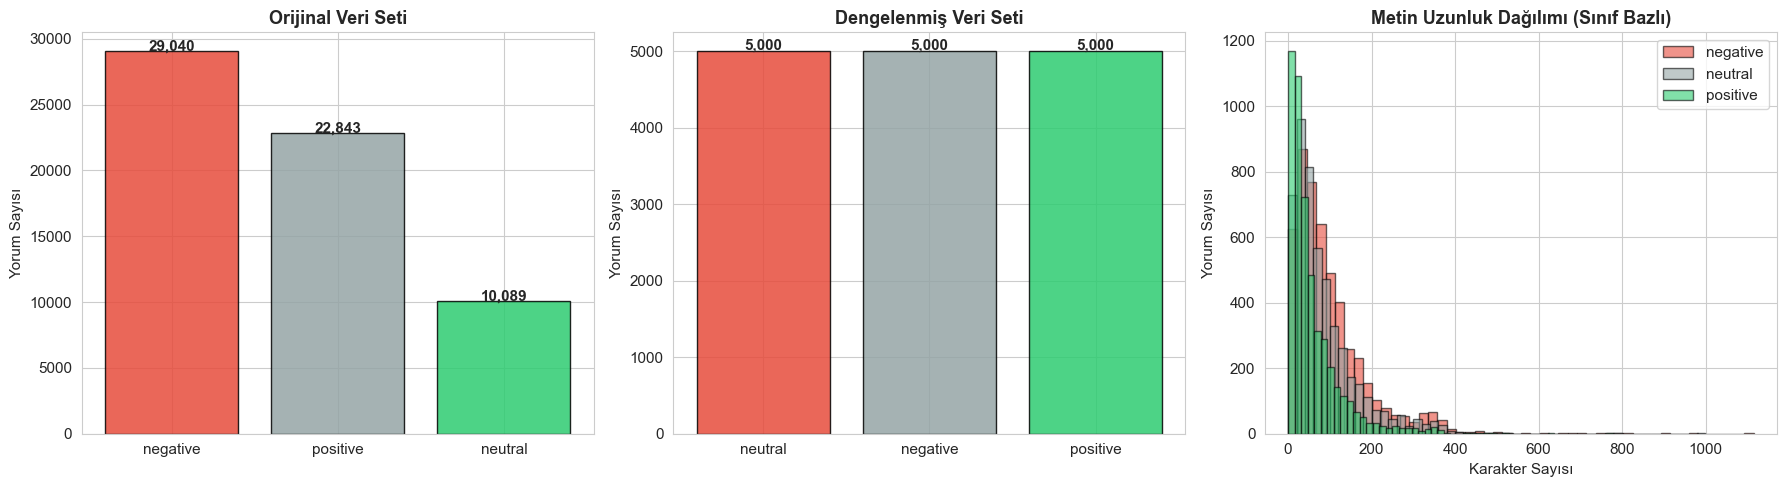


Eğitim Seti: 12,000 örnek
Test Seti:   3,000 örnek


In [9]:
# Veri Setini Yükleme
df = pd.read_csv('data/processed/reviews_cleaned.csv')
df = df.dropna(subset=['yorum']).reset_index(drop=True)

print(f"Toplam Veri: {len(df):,} yorum")
print(f"Ortalama Metin Uzunluğu: {df['yorum'].str.len().mean():.0f} karakter")
print(f"\n--- Orijinal Sınıf Dağılımı ---")
display(df['label'].value_counts().to_frame())

# Dengeli alt küme
df_pos = df[df['label'] == 'positive']
df_neg = df[df['label'] == 'negative']
df_neu = df[df['label'] == 'neutral']

sample_size = min(5000, len(df_pos), len(df_neg), len(df_neu))
print(f"\nHer sınıftan alınan örnek sayısı: {sample_size:,}")
print(f"Toplam dengeli veri: {sample_size * 3:,}")

sample_pos = df_pos.sample(n=sample_size, random_state=SEED)
sample_neg = df_neg.sample(n=sample_size, random_state=SEED)
sample_neu = df_neu.sample(n=sample_size, random_state=SEED)

df_balanced = pd.concat([sample_pos, sample_neg, sample_neu]).sample(frac=1, random_state=SEED).reset_index(drop=True)
df_balanced['label_id'] = df_balanced['label'].map(label2id)

# Sınıf dağılımı grafikleri
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#e74c3c', '#95a5a6', '#2ecc71']

# 1) Orijinal dağılım
counts_orig = df['label'].value_counts()
axes[0].bar(counts_orig.index, counts_orig.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Orijinal Veri Seti', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Yorum Sayısı')
for i, (idx, val) in enumerate(counts_orig.items()):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontweight='bold')

# 2) Dengelenmiş dağılım
counts_bal = df_balanced['label'].value_counts()
axes[1].bar(counts_bal.index, counts_bal.values, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Dengelenmiş Veri Seti', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Yorum Sayısı')
for i, (idx, val) in enumerate(counts_bal.items()):
    axes[1].text(i, val + 20, f'{val:,}', ha='center', fontweight='bold')

# 3) Metin uzunluk dağılımı
for label_name, color in zip(['negative', 'neutral', 'positive'], colors):
    subset = df_balanced[df_balanced['label'] == label_name]['cleaned_text'].str.len()
    axes[2].hist(subset, bins=50, alpha=0.6, color=color, label=label_name, edgecolor='black')
axes[2].set_title('Metin Uzunluk Dağılımı (Sınıf Bazlı)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Karakter Sayısı')
axes[2].set_ylabel('Yorum Sayısı')
axes[2].legend()

plt.tight_layout()
plt.show()

# Train-Test Split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_balanced['yorum'].tolist(),
    df_balanced['label_id'].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=df_balanced['label_id'].tolist()
)

print(f"\nEğitim Seti: {len(train_texts):,} örnek")
print(f"Test Seti:   {len(test_texts):,} örnek")


## Bölüm 4 — Tokenizasyon (Metinlerin Sayısallaştırılması)

BERT modeli metinleri doğrudan okuyamaz. Önce **tokenizer** ile her metin, modelin sözlüğündeki alt-kelime (subword) birimlerine ayrılır ve sayısal ID'lere dönüştürülür.

**Parametreler:**
- `max_length=128`: Her metin en fazla 128 token uzunluğunda kesilir
- `truncation=True`: Uzun metinler kesilir  
- `padding=True`: Kısa metinler `[PAD]` token'ları ile doldurulur

**Çıktı Tensörleri:**
- `input_ids`: Token ID dizisi
- `attention_mask`: Gerçek token (1) vs padding (0) maskesi


In [10]:
class SentimentDataset(torch.utils.data.Dataset):
    """Tokenize edilmiş verileri PyTorch Dataset formatında tutan sınıf."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Tokenizasyon
print("Tokenizasyon başlıyor...")
t0 = time.time()
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings  = tokenizer(test_texts,  truncation=True, padding=True, max_length=128)
print(f"Tokenizasyon tamamlandı ({time.time()-t0:.1f} saniye)")

train_dataset = SentimentDataset(train_encodings, train_labels)
test_dataset  = SentimentDataset(test_encodings,  test_labels)

print(f"\nEğitim seti: {len(train_dataset):,} örnek tokenize edildi")
print(f"Test seti:   {len(test_dataset):,} örnek tokenize edildi")

# Örnek token inceleme
sample = train_dataset[0]
sample_text = train_texts[0]
sample_tokens = tokenizer.convert_ids_to_tokens(sample['input_ids'].tolist())

print(f"\n--- Örnek Token İnceleme ---")
print(f"Metin:        '{sample_text[:80]}...'")
print(f"Token Sayısı: {len(sample['input_ids'])}")
print(f"Etiket:       {id2label[sample['labels'].item()]}")
print(f"\nİlk 15 Token:")
for i, (tid, tok) in enumerate(zip(sample['input_ids'][:15].tolist(), sample_tokens[:15])):
    print(f"  [{i:2d}] ID={tid:5d} -> '{tok}'")


Tokenizasyon başlıyor...
Tokenizasyon tamamlandı (0.3 saniye)

Eğitim seti: 12,000 örnek tokenize edildi
Test seti:   3,000 örnek tokenize edildi

--- Örnek Token İnceleme ---
Metin:        'Sürekli güncelleme gerisi iyi...'
Token Sayısı: 128
Etiket:       neutral

İlk 15 Token:
  [ 0] ID=    2 -> '[CLS]'
  [ 1] ID=11930 -> 'Sürekli'
  [ 2] ID=15093 -> 'güncelleme'
  [ 3] ID= 3135 -> 'geri'
  [ 4] ID= 2462 -> '##si'
  [ 5] ID= 2395 -> 'iyi'
  [ 6] ID=    3 -> '[SEP]'
  [ 7] ID=    0 -> '[PAD]'
  [ 8] ID=    0 -> '[PAD]'
  [ 9] ID=    0 -> '[PAD]'
  [10] ID=    0 -> '[PAD]'
  [11] ID=    0 -> '[PAD]'
  [12] ID=    0 -> '[PAD]'
  [13] ID=    0 -> '[PAD]'
  [14] ID=    0 -> '[PAD]'


## Bölüm 5 — Eğitim Parametrelerinin Belirlenmesi

HuggingFace `Trainer` sınıfı, eğitim döngüsünü (epoch), öğrenme oranını (learning rate), batch boyutunu ve değerlendirme stratejisini tek bir konfigürasyon ile yönetir.

### Seçilen Hiperparametreler
| Parametre | Değer | Açıklama |
|---|---|---|
| `num_train_epochs` | 3 | Veri seti üzerinde 3 tam tur |
| `per_device_train_batch_size` | 16 | Her iterasyonda 16 örnek (GPU RAM'e uygun) |
| `learning_rate` | 2e-5 | BERT için standart fine-tuning öğrenme oranı |
| `warmup_steps` | 100 | İlk 100 adımda öğrenme oranı kademeli artar |
| `weight_decay` | 0.01 | Overfitting'i engelleyen L2 düzenlileştirme |
| `eval_strategy` | "epoch" | Her epoch sonunda test seti değerlendirmesi |
| `load_best_model_at_end` | True | En iyi checkpoint otomatik yüklenir |
| `metric_for_best_model` | "f1" | En iyi model F1 skoruna göre seçilir |


In [11]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,
    fp16=True,
    lr_scheduler_type="cosine_with_restarts",
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    seed=SEED
)

# Başarı Metriklerini Hesaplayan Fonksiyon
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

total_steps = len(train_dataset) // training_args.per_device_train_batch_size * int(training_args.num_train_epochs)

print("=" * 60)
print("  EĞİTİM KONFIGÜRASYONU")
print("=" * 60)
print(f"  Cihaz:              {training_args.device}")
print(f"  Epoch Sayısı:       {int(training_args.num_train_epochs)}")
print(f"  Batch Boyutu:       {training_args.per_device_train_batch_size}")
print(f"  Öğrenme Oranı:      {training_args.learning_rate}")
print(f"  Toplam Adım:        ~{total_steps}")
print(f"  Warmup Adımları:    {training_args.warmup_steps}")
print(f"  Weight Decay:       {training_args.weight_decay}")
print(f"  En İyi Model Kriteri: {training_args.metric_for_best_model}")
print("=" * 60)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


  EĞİTİM KONFIGÜRASYONU
  Cihaz:              cuda:0
  Epoch Sayısı:       4
  Batch Boyutu:       16
  Öğrenme Oranı:      3e-05
  Toplam Adım:        ~3000
  Warmup Adımları:    100
  Weight Decay:       0.01
  En İyi Model Kriteri: f1


## Bölüm 6 — Model Eğitimi (Fine-Tuning) 🚀

GPU gücünün devreye girdiği yer burasıdır. Model, verdiğimiz binlerce örneği inceleyip hatalarından ders çıkararak (**Backpropagation**) kendi ağırlıklarını güncelleyecektir.

**Eğitim Süreci:**
1. Her epoch'ta tüm eğitim verisi batch'ler halinde modelden geçirilir
2. Model tahminleri ile gerçek etiketler karşılaştırılarak kayıp (loss) hesaplanır
3. Kayıp değeri geriye yayılarak (backpropagation) ağırlıklar güncellenir
4. Her epoch sonunda test seti üzerinde değerlendirme yapılır
5. En düşük kayıp/en yüksek F1'e sahip checkpoint en iyi model olarak seçilir


In [12]:
print("=" * 60)
print("  🚀 BERT FINE-TUNING EĞİTİMİ BAŞLIYOR")
print("=" * 60)
print(f"  Eğitim Seti:  {len(train_dataset):,} örnek")
print(f"  Test Seti:    {len(test_dataset):,} örnek")
print(f"  GPU:          {torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'}")
print("=" * 60)

start_time = time.time()
train_result = trainer.train()
elapsed = time.time() - start_time

minutes = int(elapsed // 60)
seconds = int(elapsed % 60)

print(f"\n{'=' * 60}")
print(f"  ✅ EĞİTİM TAMAMLANDI!")
print(f"  Süre: {minutes} dakika {seconds} saniye")
print(f"{'=' * 60}")

# Eğitim metrikleri
train_metrics = train_result.metrics
print(f"\n--- Eğitim Metrikleri ---")
for k, v in train_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Modelin kalıcı olarak kaydedilmesi
save_path = "./my_bert_model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"\n💾 Fine-Tuned model '{save_path}' klasörüne kaydedildi.")

# GPU bellek durumu
if device == 'cuda':
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    reserved = torch.cuda.memory_reserved(0) / 1024**3
    print(f"\n--- GPU Bellek Kullanımı ---")
    print(f"  Ayrılan: {allocated:.2f} GB")
    print(f"  Rezerve: {reserved:.2f} GB")


  🚀 BERT FINE-TUNING EĞİTİMİ BAŞLIYOR
  Eğitim Seti:  12,000 örnek
  Test Seti:    3,000 örnek
  GPU:          CPU


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.661222,0.791454,0.651667,0.655896,0.687806,0.651667
2,1.530362,0.777402,0.650333,0.656898,0.699397,0.650333
3,1.333802,0.804939,0.657667,0.662264,0.675011,0.657667
4,1.089374,0.841668,0.657333,0.661715,0.672285,0.657333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  ✅ EĞİTİM TAMAMLANDI!
  Süre: 7 dakika 18 saniye

--- Eğitim Metrikleri ---
  train_runtime: 436.9449
  train_samples_per_second: 109.8540
  train_steps_per_second: 3.4330
  total_flos: 3157361012736000.0000
  train_loss: 1.4476
  epoch: 4.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


💾 Fine-Tuned model './my_bert_model' klasörüne kaydedildi.


## Bölüm 7 — Eğitim Sürecinin Görselleştirilmesi

Eğitim sırasında kaydedilen kayıp (loss) ve metrik değerlerini görselleştirerek modelin öğrenme davranışını analiz ediyoruz.

- **Training Loss'un azalması:** Model veriden başarılı şekilde öğreniyor
- **Eval Loss'un azalması:** Model genelleme yapabiliyor (overfitting yok)
- **Eval Loss artarken Training Loss azalıyorsa:** Overfitting belirtisi


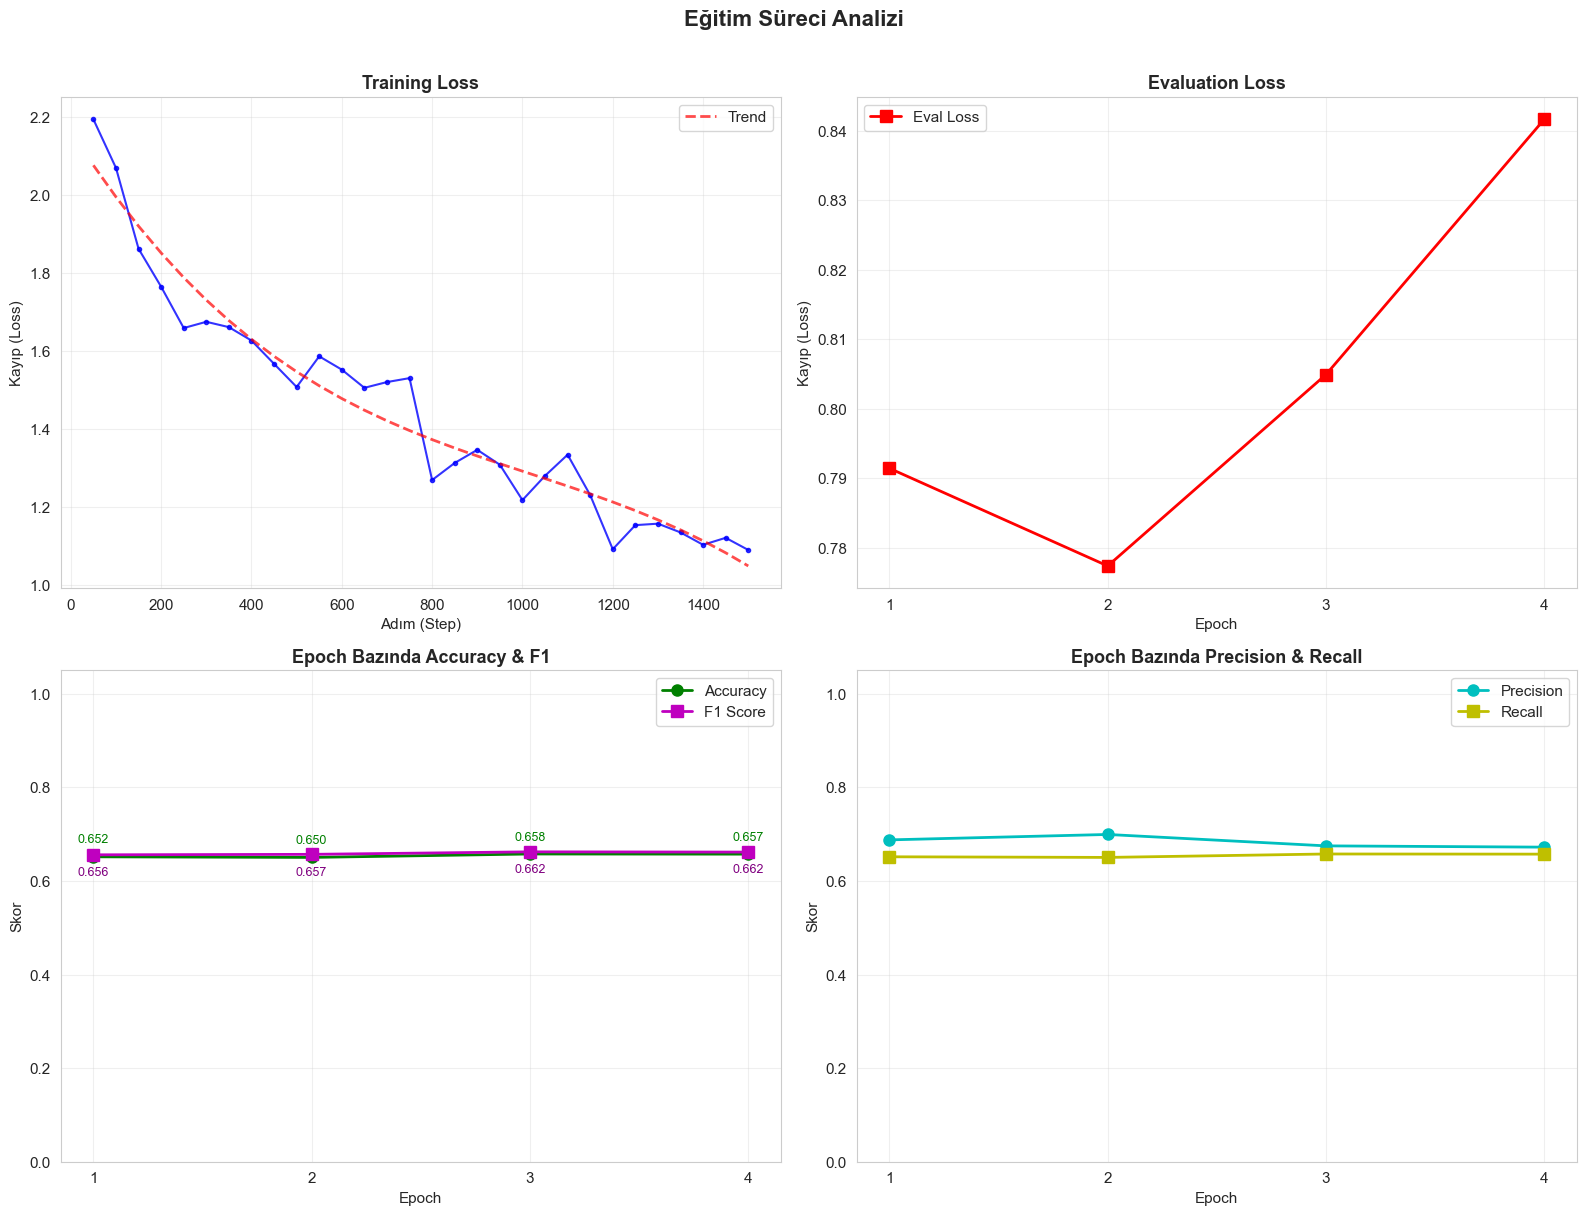


--- Epoch Bazında Detaylı Metrikler ---


Epoch,Eval Loss,Accuracy,F1,Precision,Recall
1,0.7915,0.6517,0.6559,0.6878,0.6517
2,0.7774,0.6503,0.6569,0.6994,0.6503
3,0.8049,0.6577,0.6623,0.6750,0.6577
4,0.8417,0.6573,0.6617,0.6723,0.6573


In [13]:
log_history = trainer.state.log_history

train_losses = [(x['step'], x['loss']) for x in log_history if 'loss' in x]
eval_data = [x for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Training Loss
if train_losses:
    steps, losses = zip(*train_losses)
    axes[0, 0].plot(steps, losses, 'b-o', markersize=3, linewidth=1.5, alpha=0.8)
    axes[0, 0].set_xlabel('Adım (Step)')
    axes[0, 0].set_ylabel('Kayıp (Loss)')
    axes[0, 0].set_title('Training Loss', fontsize=13, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    # Trend çizgisi
    z = np.polyfit(steps, losses, 3)
    p = np.poly1d(z)
    axes[0, 0].plot(steps, p(steps), 'r--', linewidth=2, alpha=0.7, label='Trend')
    axes[0, 0].legend()

# 2) Eval Loss
if eval_data:
    epochs = list(range(1, len(eval_data) + 1))
    eval_losses = [x['eval_loss'] for x in eval_data]
    axes[0, 1].plot(epochs, eval_losses, 'r-s', markersize=8, linewidth=2, label='Eval Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Kayıp (Loss)')
    axes[0, 1].set_title('Evaluation Loss', fontsize=13, fontweight='bold')
    axes[0, 1].set_xticks(epochs)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# 3) Accuracy & F1 per epoch
if eval_data:
    eval_acc = [x['eval_accuracy'] for x in eval_data]
    eval_f1  = [x['eval_f1'] for x in eval_data]
    
    axes[1, 0].plot(epochs, eval_acc, 'g-o', markersize=8, linewidth=2, label='Accuracy')
    axes[1, 0].plot(epochs, eval_f1,  'm-s', markersize=8, linewidth=2, label='F1 Score')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Skor')
    axes[1, 0].set_title('Epoch Bazında Accuracy & F1', fontsize=13, fontweight='bold')
    axes[1, 0].set_xticks(epochs)
    axes[1, 0].legend(fontsize=11)
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Değerleri üzerine yaz
    for i, (a, f) in enumerate(zip(eval_acc, eval_f1)):
        axes[1, 0].annotate(f'{a:.3f}', (epochs[i], a), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='green')
        axes[1, 0].annotate(f'{f:.3f}', (epochs[i], f), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, color='purple')

# 4) Precision & Recall per epoch
if eval_data:
    eval_prec = [x['eval_precision'] for x in eval_data]
    eval_rec  = [x['eval_recall'] for x in eval_data]
    
    axes[1, 1].plot(epochs, eval_prec, 'c-o', markersize=8, linewidth=2, label='Precision')
    axes[1, 1].plot(epochs, eval_rec,  'y-s', markersize=8, linewidth=2, label='Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Skor')
    axes[1, 1].set_title('Epoch Bazında Precision & Recall', fontsize=13, fontweight='bold')
    axes[1, 1].set_xticks(epochs)
    axes[1, 1].legend(fontsize=11)
    axes[1, 1].set_ylim(0, 1.05)
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Eğitim Süreci Analizi', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Epoch tablosu
if eval_data:
    print("\n--- Epoch Bazında Detaylı Metrikler ---")
    epoch_df = pd.DataFrame({
        'Epoch': epochs,
        'Eval Loss': [f"{x['eval_loss']:.4f}" for x in eval_data],
        'Accuracy': [f"{x['eval_accuracy']:.4f}" for x in eval_data],
        'F1': [f"{x['eval_f1']:.4f}" for x in eval_data],
        'Precision': [f"{x['eval_precision']:.4f}" for x in eval_data],
        'Recall': [f"{x['eval_recall']:.4f}" for x in eval_data],
    })
    display(epoch_df.style.hide(axis='index'))


## Bölüm 8 — Test Seti Değerlendirmesi

Eğitilmiş modelimizi test seti üzerinde çalıştırarak nihai performansını ölçüyoruz:
- **Classification Report:** Sınıf bazlı Precision, Recall, F1
- **Confusion Matrix:** Hangi sınıfların birbiriyle karıştırıldığını gösteren matris
- **Sınıf Bazlı Performans:** Bar grafik ile görsel karşılaştırma
- **ROC Eğrisi:** Her sınıf için True Positive Rate vs False Positive Rate


Test seti üzerinden tahminler alınıyor...



  📊 FINE-TUNED BERT — TEST SONUÇLARI
  Accuracy:  0.6577  (65.8%)
  Precision: 0.6750
  Recall:    0.6577
  F1 Score:  0.6623

--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

    negative       0.64      0.69      0.67      1000
     neutral       0.54      0.61      0.58      1000
    positive       0.84      0.67      0.75      1000

    accuracy                           0.66      3000
   macro avg       0.68      0.66      0.66      3000
weighted avg       0.68      0.66      0.66      3000



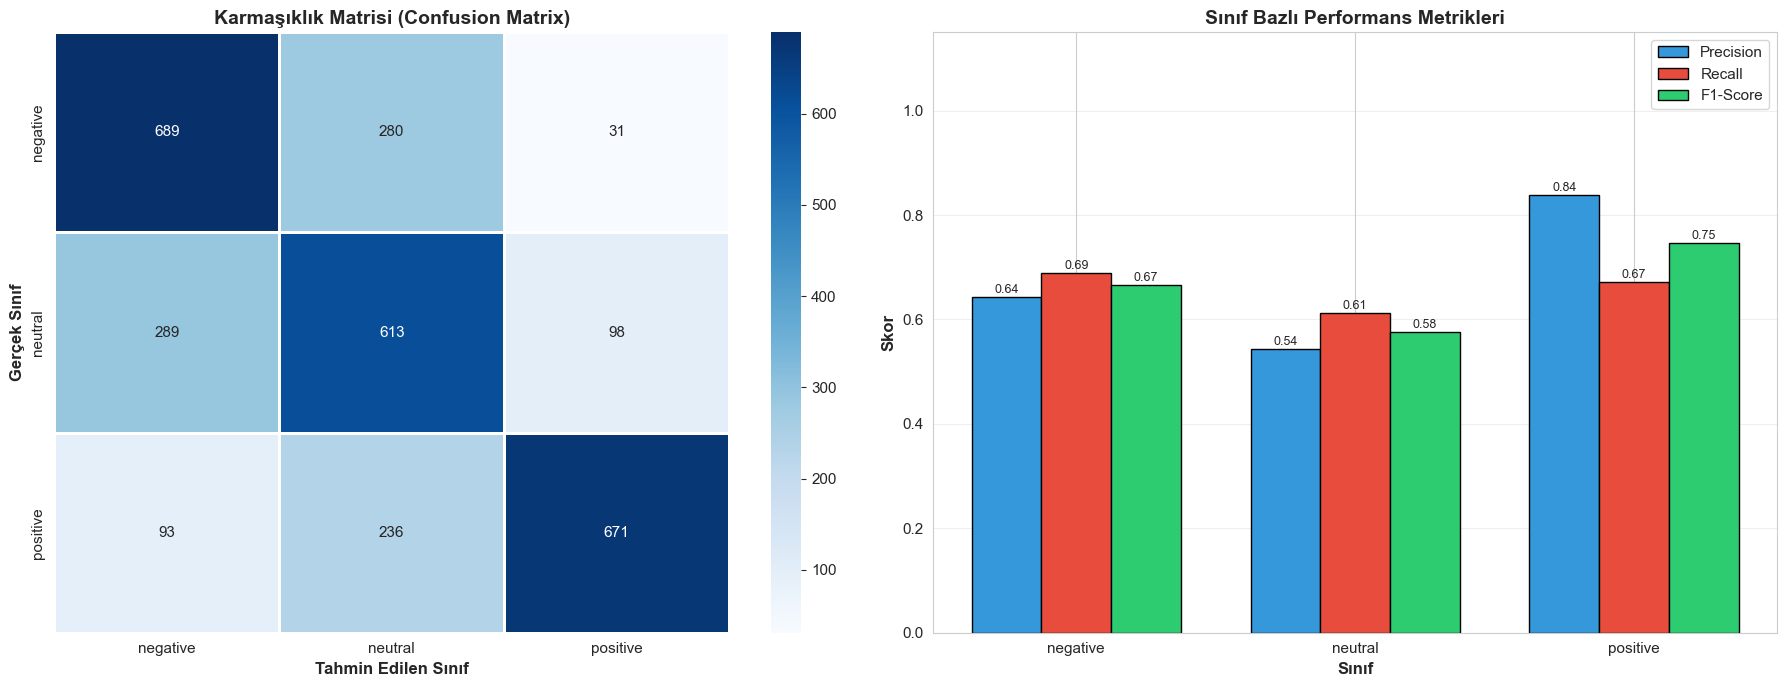

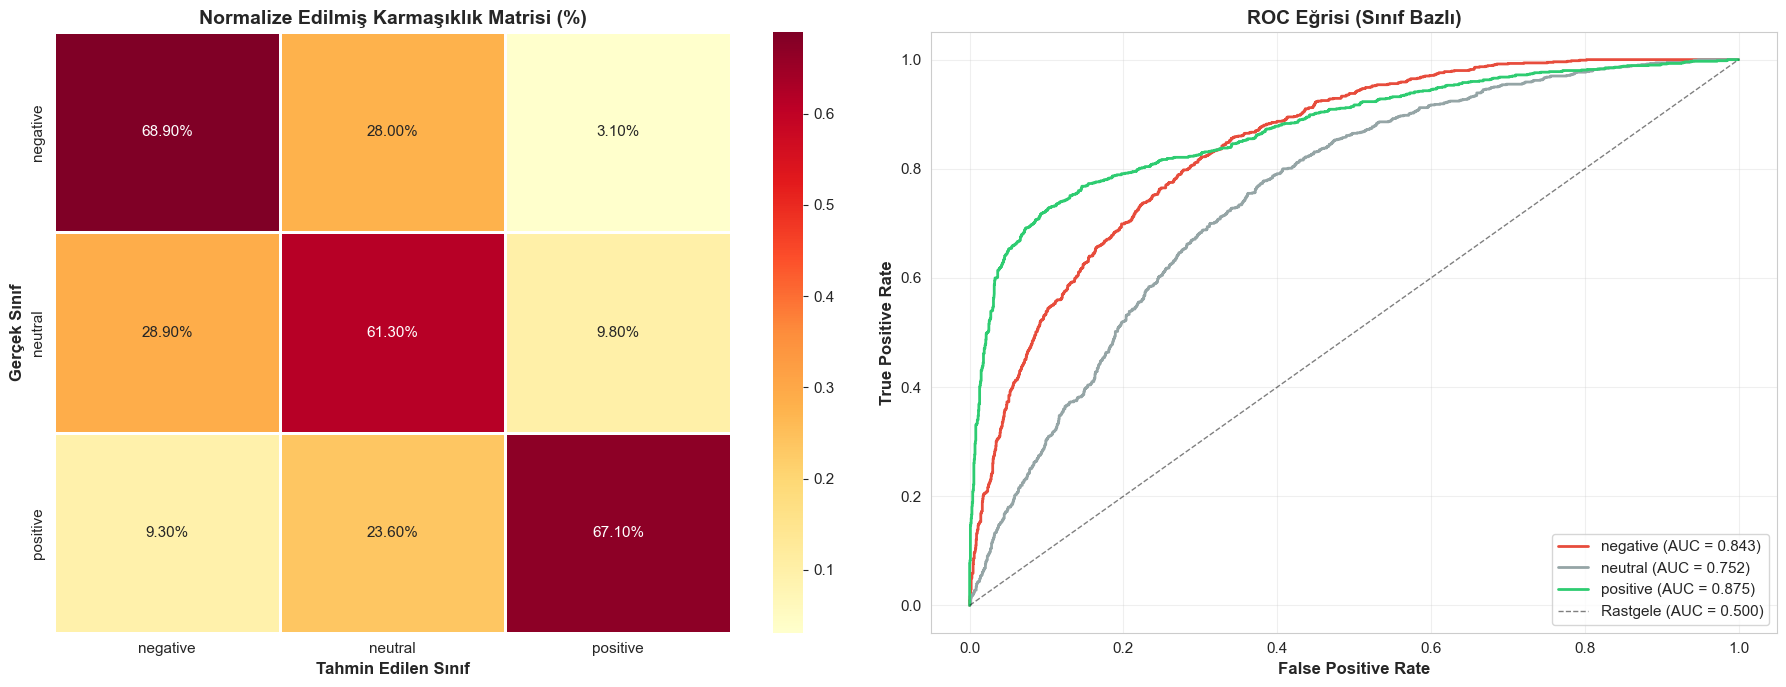

In [14]:
# Test setinde tahmin
print("Test seti üzerinden tahminler alınıyor...")
raw_pred, _, _ = trainer.predict(test_dataset)
y_pred = np.argmax(raw_pred, axis=1)
y_true = np.array(test_labels)
y_probs = torch.softmax(torch.tensor(raw_pred), dim=-1).numpy()

# Genel Metrikler
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

target_names = ['negative', 'neutral', 'positive']

print(f"\n{'=' * 55}")
print(f"  📊 FINE-TUNED BERT — TEST SONUÇLARI")
print(f"{'=' * 55}")
print(f"  Accuracy:  {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"{'=' * 55}")

# Classification Report
print("\n--- Sınıflandırma Raporu ---")
report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
print(classification_report(y_true, y_pred, target_names=target_names))

# ── Grafik 1: Confusion Matrix + Sınıf Bazlı Metrikler ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0],
            linewidths=1, linecolor='white')
axes[0].set_xlabel('Tahmin Edilen Sınıf', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Gerçek Sınıf', fontsize=12, fontweight='bold')
axes[0].set_title('Karmaşıklık Matrisi (Confusion Matrix)', fontsize=14, fontweight='bold')

# Sınıf bazlı metrikler bar grafiği
class_f1   = [report[c]['f1-score'] for c in target_names]
class_prec = [report[c]['precision'] for c in target_names]
class_rec  = [report[c]['recall'] for c in target_names]

x = np.arange(len(target_names))
width = 0.25

bars1 = axes[1].bar(x - width, class_prec, width, label='Precision', color='#3498db', edgecolor='black')
bars2 = axes[1].bar(x, class_rec, width, label='Recall', color='#e74c3c', edgecolor='black')
bars3 = axes[1].bar(x + width, class_f1, width, label='F1-Score', color='#2ecc71', edgecolor='black')

axes[1].set_xlabel('Sınıf', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Skor', fontsize=12, fontweight='bold')
axes[1].set_title('Sınıf Bazlı Performans Metrikleri', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(target_names)
axes[1].legend(fontsize=11)
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        axes[1].annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ── Grafik 2: Normalized CM + ROC Eğrisi ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Normalized Confusion Matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0],
            linewidths=1, linecolor='white')
axes[0].set_xlabel('Tahmin Edilen Sınıf', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Gerçek Sınıf', fontsize=12, fontweight='bold')
axes[0].set_title('Normalize Edilmiş Karmaşıklık Matrisi (%)', fontsize=14, fontweight='bold')

# ROC Eğrisi
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
colors_roc = ['#e74c3c', '#95a5a6', '#2ecc71']

for i, (name, color) in enumerate(zip(target_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Rastgele (AUC = 0.500)')
axes[1].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[1].set_title('ROC Eğrisi (Sınıf Bazlı)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11, loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Bölüm 9 — Örnek Tahminler İncelemesi

Eğitilmiş modelin test setindeki gerçek yorumlar üzerinde nasıl performans gösterdiğini yakından inceliyoruz. Hem doğru hem yanlış tahmin edilen örnekleri tablolar halinde gösteriyoruz.


In [15]:
# Sonuçları DataFrame'e çevirme
df_results = pd.DataFrame({
    'text': test_texts,
    'gerçek': [id2label[l] for l in y_true],
    'tahmin': [id2label[p] for p in y_pred],
    'doğru': y_true == y_pred,
    'güven': y_probs.max(axis=1),
    'neg_prob': y_probs[:, 0],
    'neu_prob': y_probs[:, 1],
    'pos_prob': y_probs[:, 2],
})

# ── Doğru Tahminler ──
print("--- ✅ Doğru Tahmin Edilen Örnekler (Rastgele 10 Tanesi) ---")
correct = df_results[df_results['doğru'] == True].sample(n=min(10, df_results['doğru'].sum()), random_state=SEED)
display(correct[['text', 'gerçek', 'tahmin', 'güven']].style.format({'güven': '{:.4f}'}).set_properties(**{'text-align': 'left'}))

# ── Yanlış Tahminler ──
wrong_count = (~df_results['doğru']).sum()
print(f"\n--- ❌ Yanlış Tahmin Edilen Örnekler ({min(10, wrong_count)} / {wrong_count} Tanesi) ---")
wrong = df_results[df_results['doğru'] == False].head(10)
display(wrong[['text', 'gerçek', 'tahmin', 'güven', 'neg_prob', 'neu_prob', 'pos_prob']].style.format({
    'güven': '{:.4f}', 'neg_prob': '{:.3f}', 'neu_prob': '{:.3f}', 'pos_prob': '{:.3f}'
}).set_properties(**{'text-align': 'left'}))

# Yanlış tahmin dağılımı
print(f"\n--- Hata Analizi ---")
print(f"  Toplam Doğru: {df_results['doğru'].sum():,} / {len(df_results):,} ({df_results['doğru'].mean()*100:.1f}%)")
print(f"  Toplam Yanlış: {wrong_count:,} / {len(df_results):,} ({wrong_count/len(df_results)*100:.1f}%)")

if wrong_count > 0:
    wrong_df = df_results[df_results['doğru'] == False]
    print(f"\n  En sık karıştırılan sınıflar:")
    confusion_pairs = wrong_df.groupby(['gerçek', 'tahmin']).size().sort_values(ascending=False)
    for (true_label, pred_label), count in confusion_pairs.head(5).items():
        print(f"    {true_label} → {pred_label}: {count} kez")


--- ✅ Doğru Tahmin Edilen Örnekler (Rastgele 10 Tanesi) ---


,text,gerçek,tahmin,güven
1132,teşekkürler,positive,positive,0.8269
439,sistem neden sürekli hata veriyor alıcagım seylerı alamıyorum sürekli hata veriyor iki gündür ugraşıyorum,neutral,neutral,0.5025
2161,sürekli uygulama içinde sorunlar yaşıyorum defalarca sildim yükledim düzelmedi.,negative,negative,0.7314
512,Ben yıllar dir bu banka ile çalışıyorum ama sb kart gelmiş ti almak için gittim.. benden sonra gelen 10kisi işlemi yaptırdı gişelerden ama ben tam bir sira gelmedi 1.5 saate bende sinirden attım sıra fişini çektim gittim kimsede sormadı neden diye ilgi yok bu sistem çözülmez se çok müşteri kayıp edersiniz....,negative,negative,0.7961
1669,Geri dönüşlerde devamlı hata veriyor,neutral,neutral,0.4684
1023,Acık her türden insanın anlıyabilceği dilden,positive,positive,0.9126
100,idare eder,neutral,neutral,0.6209
2162,uygulama iyi güzel ama şikayet ettiğimiz kişi ban yemiyor rahatça rahatsız edici kullanıcı isimleri kullanabiliiyor sözlü taciz yapabiliyor ve birde kişi arama kısmına arayıp bulma kısmına arkadaşımın ismini yazıyorum fakat doğru dürüst bisey çıkmıyor aradığımız kişiyi rahatça bulabilelim istiyorum,neutral,neutral,0.6932
80,çok güzel bir uygulama,positive,positive,0.9632
1625,cok iyi beyendim,positive,positive,0.9551



--- ❌ Yanlış Tahmin Edilen Örnekler (10 / 1027 Tanesi) ---


,text,gerçek,tahmin,güven,neg_prob,neu_prob,pos_prob
3,sifremi unuttum dogrulamada yüz tanıma sisteminde hata var uygulama çokuyor,negative,neutral,0.5096,0.394,0.510,0.096
4,N11'i beyenmedim çünkü kasıp duruyor,negative,neutral,0.5203,0.379,0.520,0.101
5,Kurumsal kart ile ödeme seçeneği çalışmıyor. Ekran boş geliyor. Lütfen bunu düzeltin,negative,neutral,0.7248,0.091,0.725,0.184
12,NFC çalışmıyor telefon güvenliği diyor ne yaptıysam çalışmadı poco f7 ultra sıfır telefon,neutral,negative,0.9544,0.954,0.028,0.018
14,Güzel ama bir sıkıntımız var komik şeyler aramak istiyorum ama bulamıyorum ama yine de beş,positive,neutral,0.5882,0.033,0.588,0.379
17,Uygulama gayet iyi fakat işveren aradığında geri dönüş yapamıyoruz bunun için bir şey yapabilir misiniz,positive,neutral,0.6441,0.039,0.644,0.317
19,"Güncellemeden önceki arayüz daha iyiydi, şimdi diğer bankalar karmaşık gibi olmuş",positive,neutral,0.4700,0.451,0.470,0.079
22,Bir başvuru veriyoruz haftalarca onaylanmasını bekliyoruz ayrıca adres de kapı numarası bile yazmaya izin vermiyor. Yani bazı şeylerin düzenlenmesi lazım İlan süresi dolduğun da geçmiş başvuru yapanları görüntülemek mantıklı olurdu,negative,neutral,0.5250,0.375,0.525,0.100
25,ilan ücreti yüksek,negative,neutral,0.6633,0.257,0.663,0.079
29,en yakın hangi maganizda secenegi olmadigi için,negative,neutral,0.6275,0.139,0.628,0.233



--- Hata Analizi ---
  Toplam Doğru: 1,973 / 3,000 (65.8%)
  Toplam Yanlış: 1,027 / 3,000 (34.2%)

  En sık karıştırılan sınıflar:
    neutral → negative: 289 kez
    negative → neutral: 280 kez
    positive → neutral: 236 kez
    neutral → positive: 98 kez
    positive → negative: 93 kez


## Bölüm 10 — Güven Skoru Dağılımı Analizi

Modelin tahminlerinde ne kadar "emin" olduğunu güven skoru (confidence) dağılımı üzerinden inceliyoruz. İdeal bir modelde:
- **Doğru tahminlerde:** Güven skoru yüksek olmalı (~1.0'a yakın)
- **Yanlış tahminlerde:** Güven skoru düşük olmalı (model emin olmamalı)

Yüksek güvenle yapılan yanlış tahminler modelin "aşırı özgüvenli" olduğu durumları gösterir.


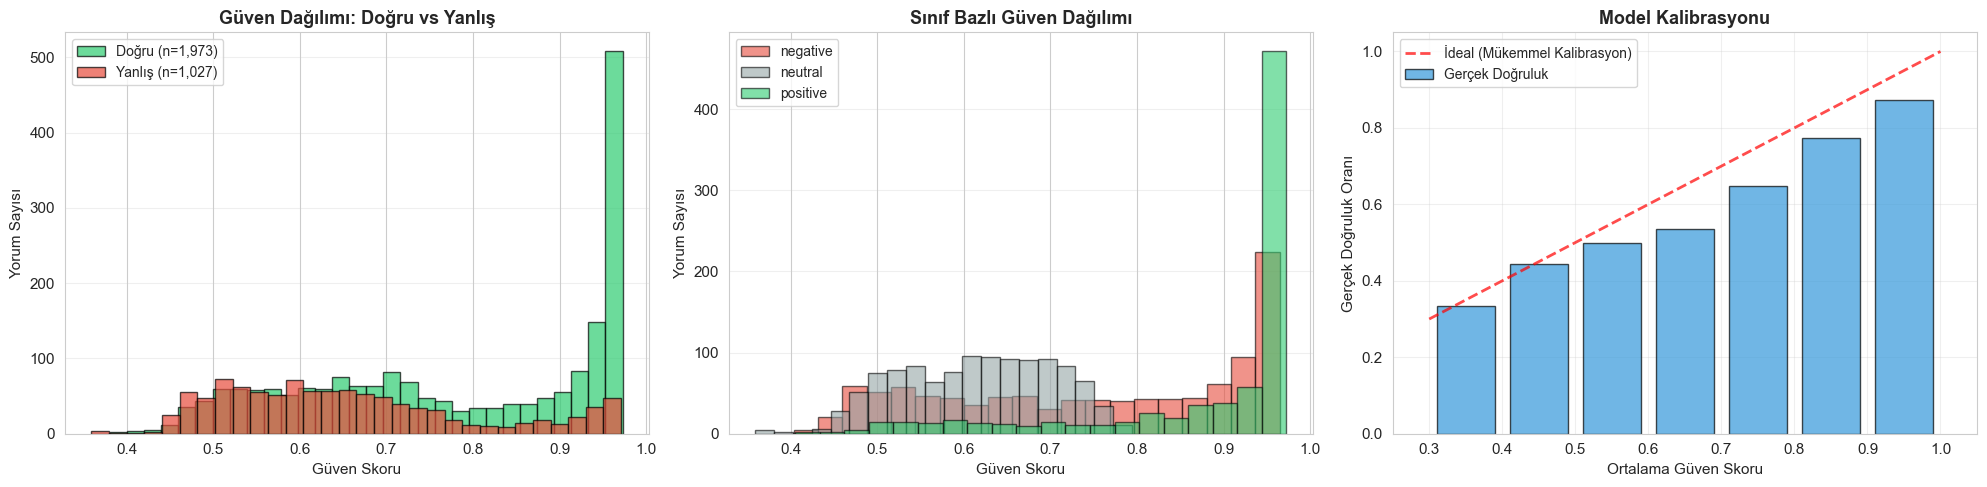

--- Güven Skoru İstatistikleri ---
  Doğru tahminler  - Ortalama: 0.7789, Medyan: 0.7960
  Yanlış tahminler - Ortalama: 0.6538, Medyan: 0.6272
  Yüksek güvenle (>0.9) yanlış: 115 (11.2%)


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

correct_conf = df_results[df_results['doğru'] == True]['güven']
wrong_conf   = df_results[df_results['doğru'] == False]['güven']

# 1) Doğru vs Yanlış
axes[0].hist(correct_conf, bins=30, alpha=0.7, color='#2ecc71', label=f'Doğru (n={len(correct_conf):,})', edgecolor='black')
axes[0].hist(wrong_conf, bins=30, alpha=0.7, color='#e74c3c', label=f'Yanlış (n={len(wrong_conf):,})', edgecolor='black')
axes[0].set_xlabel('Güven Skoru')
axes[0].set_ylabel('Yorum Sayısı')
axes[0].set_title('Güven Dağılımı: Doğru vs Yanlış', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# 2) Sınıf bazlı güven
for label_name, color in zip(target_names, ['#e74c3c', '#95a5a6', '#2ecc71']):
    mask = df_results['tahmin'] == label_name
    axes[1].hist(df_results[mask]['güven'], bins=20, alpha=0.6, color=color, label=label_name, edgecolor='black')
axes[1].set_xlabel('Güven Skoru')
axes[1].set_ylabel('Yorum Sayısı')
axes[1].set_title('Sınıf Bazlı Güven Dağılımı', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# 3) Güven skoruna göre doğruluk oranı (calibration)
bins = np.linspace(0.3, 1.0, 8)
bin_accs = []
bin_confs = []
bin_counts = []
for i in range(len(bins) - 1):
    mask = (df_results['güven'] >= bins[i]) & (df_results['güven'] < bins[i+1])
    if mask.sum() > 0:
        bin_accs.append(df_results[mask]['doğru'].mean())
        bin_confs.append((bins[i] + bins[i+1]) / 2)
        bin_counts.append(mask.sum())

axes[2].bar(bin_confs, bin_accs, width=0.08, alpha=0.7, color='#3498db', edgecolor='black', label='Gerçek Doğruluk')
axes[2].plot([0.3, 1.0], [0.3, 1.0], 'r--', linewidth=2, alpha=0.7, label='İdeal (Mükemmel Kalibrasyon)')
axes[2].set_xlabel('Ortalama Güven Skoru')
axes[2].set_ylabel('Gerçek Doğruluk Oranı')
axes[2].set_title('Model Kalibrasyonu', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].set_xlim(0.25, 1.05)
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# İstatistikler
print("--- Güven Skoru İstatistikleri ---")
print(f"  Doğru tahminler  - Ortalama: {correct_conf.mean():.4f}, Medyan: {correct_conf.median():.4f}")
if len(wrong_conf) > 0:
    print(f"  Yanlış tahminler - Ortalama: {wrong_conf.mean():.4f}, Medyan: {wrong_conf.median():.4f}")
    high_conf_wrong = (wrong_conf > 0.9).sum()
    print(f"  Yüksek güvenle (>0.9) yanlış: {high_conf_wrong} ({high_conf_wrong/len(wrong_conf)*100:.1f}%)")


## Bölüm 11 — Attention (Dikkat) Haritası Görselleştirmesi

BERT modelinin bir cümleyi sınıflandırırken **hangi kelimelere daha çok dikkat ettiğini** (attention weight) görselleştiriyoruz. Bu, modelin karar mekanizmasını anlamamıza yardımcı olur.

Yüksek attention ağırlığına sahip kelimeler, modelin sınıflandırma kararında en etkili olan kelimelerdir.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

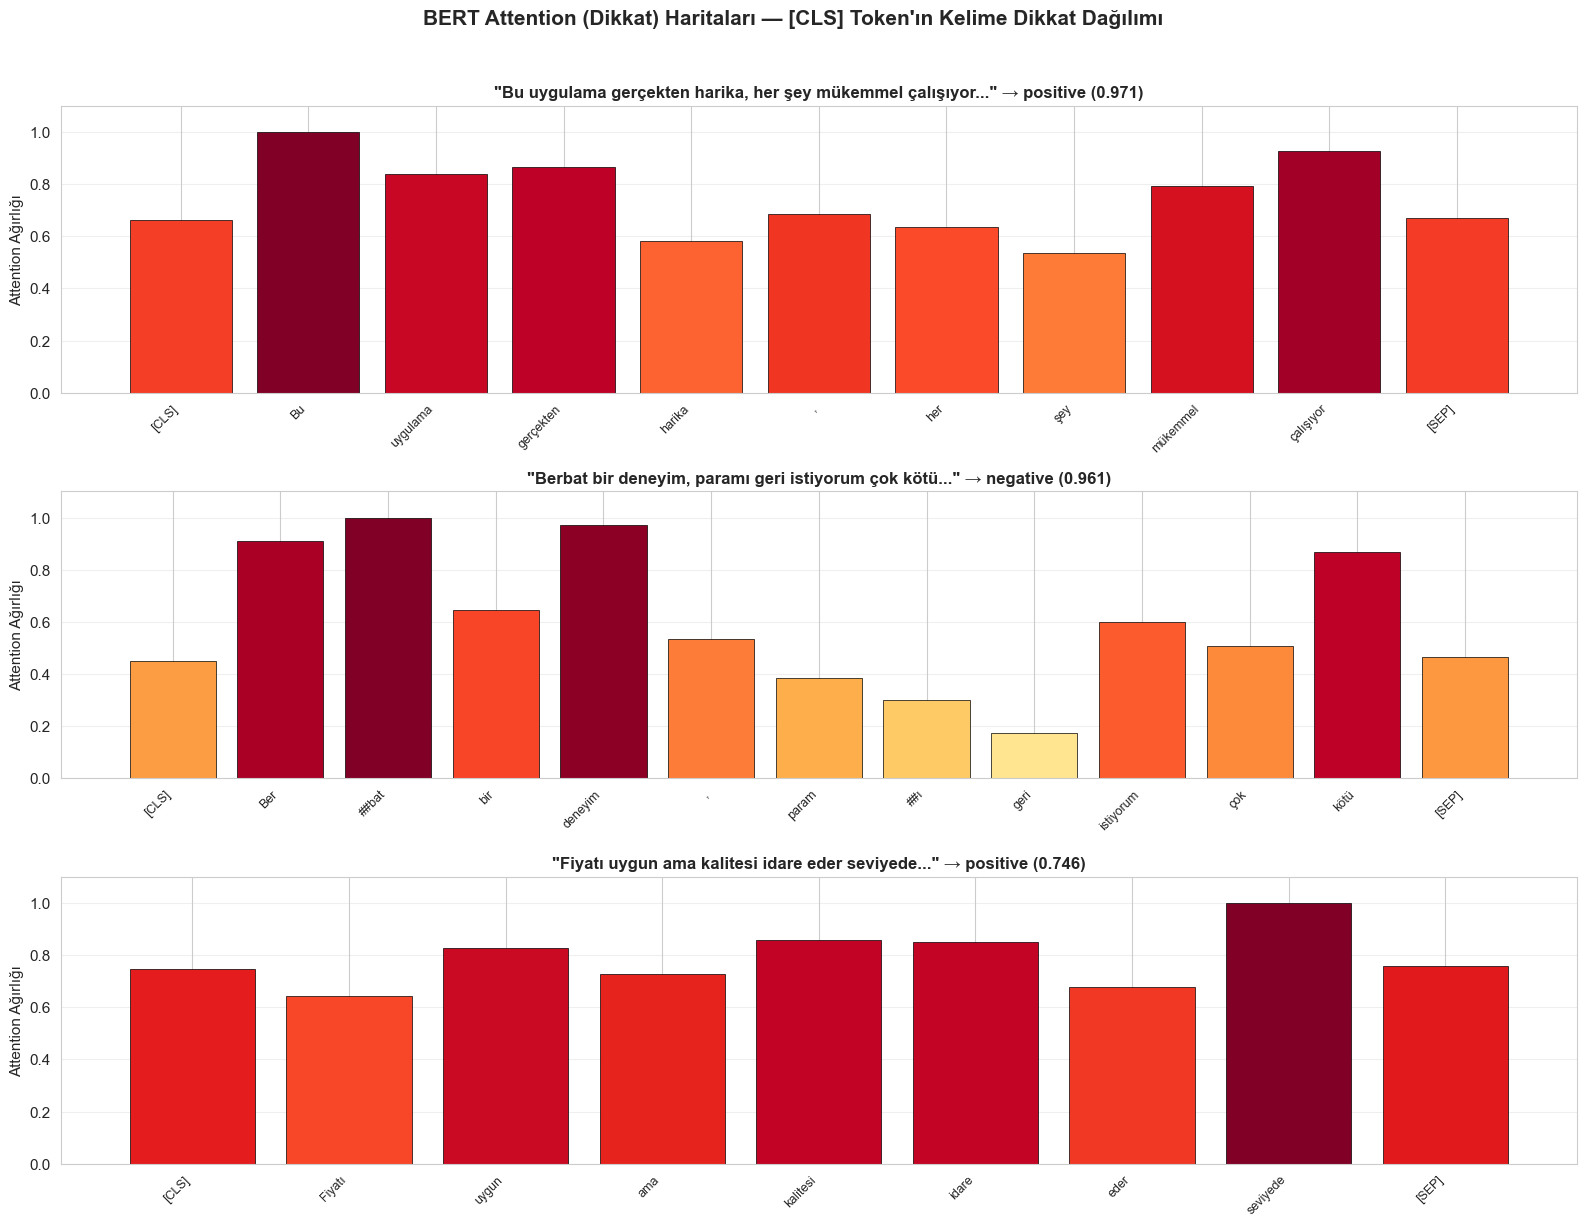

In [17]:
# Hata almamak için eğittiğimiz modeli diskten 'eager' modunda (Tüm ağırlıkları gösterecek şekilde) geri çağırıyoruz
model_dir = "./my_bert_model"
model = AutoModelForSequenceClassification.from_pretrained(
    model_dir, 
    attn_implementation="eager"
).to(device)

# Attention çıktılarını aktif et ve test moduna al
model.config.output_attentions = True
model.eval()

attention_examples = [
    "Bu uygulama gerçekten harika, her şey mükemmel çalışıyor",
    "Berbat bir deneyim, paramı geri istiyorum çok kötü",
    "Fiyatı uygun ama kalitesi idare eder seviyede"
]

fig, axes = plt.subplots(len(attention_examples), 1, figsize=(16, 4 * len(attention_examples)))

for idx, text in enumerate(attention_examples):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    
    # Son katmanın attention ortalaması
    attention = outputs.attentions[-1]  # Son katman
    attention_avg = attention.mean(dim=1).squeeze(0)  # Head ortalaması
    
    # CLS token'ının diğer token'lara verdiği attention
    cls_attention = attention_avg[0].cpu().numpy()
    
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].cpu().tolist())
    
    # [PAD] token'larını filtrele
    valid_len = (inputs['attention_mask'][0] == 1).sum().item()
    tokens = tokens[:valid_len]
    cls_attention = cls_attention[:valid_len]
    
    # Normalize et
    cls_attention = cls_attention / cls_attention.max()
    
    # Tahmin
    probs = torch.softmax(outputs.logits, dim=-1)
    pred_id = probs.argmax().item()
    pred_label = id2label[pred_id]
    pred_conf = probs[0][pred_id].item()
    
    # Görselleştirme
    ax = axes[idx] if len(attention_examples) > 1 else axes
    colors_att = plt.cm.YlOrRd(cls_attention)
    bars = ax.bar(range(len(tokens)), cls_attention, color=colors_att, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Attention Ağırlığı')
    ax.set_title(f'"{text[:60]}..." → {pred_label} ({pred_conf:.3f})', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('BERT Attention (Dikkat) Haritaları — [CLS] Token\'ın Kelime Dikkat Dağılımı', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Bölüm 12 — Zero-Shot vs Fine-Tuned Karşılaştırma

Önceki notebook'taki Zero-Shot (eğitimsiz) sonuçlar ile bu notebook'taki Fine-Tuned sonuçları yan yana koyarak **eğitimin ne kadar fark yarattığını** somut olarak gösteriyoruz.


  📊 ZERO-SHOT vs FINE-TUNED KARŞILAŞTIRMA


Metrik,Zero-Shot,Fine-Tuned,Fark,İyileşme Oranı
Accuracy,0.7110,0.6577,-5.33%,-7.5%
Precision,0.7646,0.6750,-8.96%,-11.7%
Recall,0.7110,0.6577,-5.33%,-7.5%
F1 Score,0.6956,0.6623,-3.33%,-4.8%


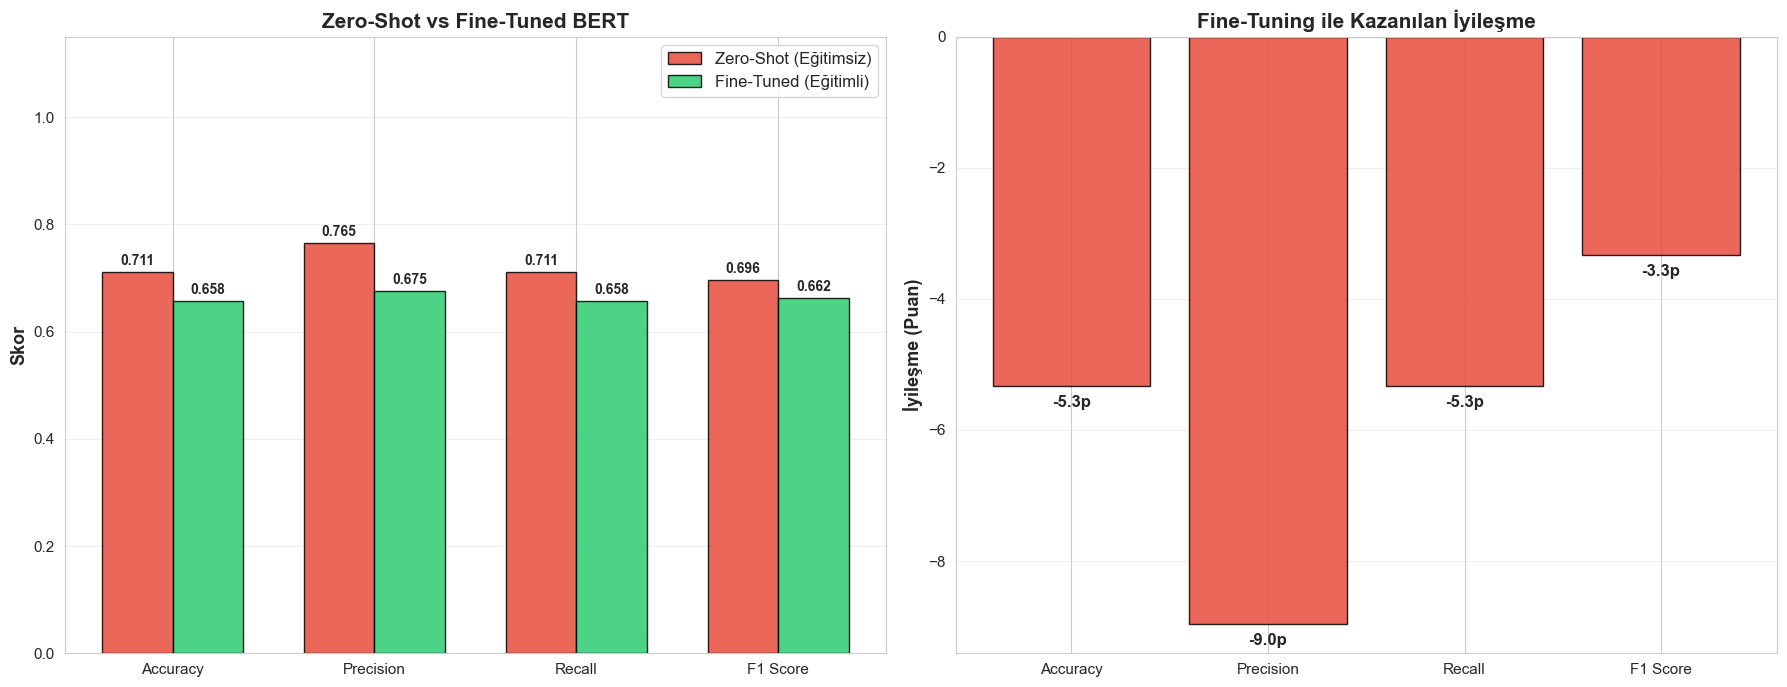

In [18]:
# Önceki notebook'tan Zero-Shot sonuçları
zero_shot = {
    'Accuracy': 0.7110,
    'Precision': 0.7646,
    'Recall': 0.7110,
    'F1 Score': 0.6956
}

fine_tuned = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1
}

# Karşılaştırma tablosu
df_compare = pd.DataFrame({
    'Metrik': list(zero_shot.keys()),
    'Zero-Shot': [f"{v:.4f}" for v in zero_shot.values()],
    'Fine-Tuned': [f"{v:.4f}" for v in fine_tuned.values()],
    'Fark': [f"{(ft-zs)*100:+.2f}%" for zs, ft in zip(zero_shot.values(), fine_tuned.values())],
    'İyileşme Oranı': [f"{((ft-zs)/zs)*100:+.1f}%" if zs > 0 else "N/A" 
                        for zs, ft in zip(zero_shot.values(), fine_tuned.values())]
})

print("=" * 65)
print("  📊 ZERO-SHOT vs FINE-TUNED KARŞILAŞTIRMA")
print("=" * 65)
display(df_compare.style.hide(axis='index'))

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar karşılaştırma
x = np.arange(len(zero_shot))
width = 0.35

bars1 = axes[0].bar(x - width/2, zero_shot.values(), width, label='Zero-Shot (Eğitimsiz)', 
                     color='#e74c3c', edgecolor='black', alpha=0.85)
bars2 = axes[0].bar(x + width/2, fine_tuned.values(), width, label='Fine-Tuned (Eğitimli)', 
                     color='#2ecc71', edgecolor='black', alpha=0.85)

axes[0].set_ylabel('Skor', fontsize=13, fontweight='bold')
axes[0].set_title('Zero-Shot vs Fine-Tuned BERT', fontsize=15, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(zero_shot.keys(), fontsize=11)
axes[0].legend(fontsize=12)
axes[0].set_ylim(0, 1.15)
axes[0].grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        axes[0].annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 5), textcoords="offset points", ha='center', fontsize=10, fontweight='bold')

# İyileşme miktarı
improvements = [(ft - zs) * 100 for zs, ft in zip(zero_shot.values(), fine_tuned.values())]
colors_imp = ['#2ecc71' if v >= 0 else '#e74c3c' for v in improvements]
bars = axes[1].bar(list(zero_shot.keys()), improvements, color=colors_imp, edgecolor='black', alpha=0.85)
axes[1].set_ylabel('İyileşme (Puan)', fontsize=13, fontweight='bold')
axes[1].set_title('Fine-Tuning ile Kazanılan İyileşme', fontsize=15, fontweight='bold')
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, improvements):
    h = bar.get_height()
    axes[1].annotate(f'{val:+.1f}p', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 5 if h >= 0 else -15), textcoords="offset points", 
                    ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## Bölüm 13 — Sonuçların Dışa Aktarılması

Tüm metrikleri JSON formatında kaydederek model karşılaştırma notebook'unda (05) kullanıma hazır hale getiriyoruz.


In [19]:
# Sonuçları JSON olarak kaydetme
results_dict = {
    "model_name": "BERT Fine-Tuned",
    "base_model": model_name,
    "model_path": save_path,
    "training_config": {
        "epochs": int(training_args.num_train_epochs),
        "batch_size": training_args.per_device_train_batch_size,
        "learning_rate": training_args.learning_rate,
        "warmup_steps": training_args.warmup_steps,
        "weight_decay": training_args.weight_decay,
        "seed": SEED
    },
    "data_info": {
        "total_samples": len(df),
        "balanced_samples": len(df_balanced),
        "training_samples": len(train_dataset),
        "test_samples": len(test_dataset),
        "classes": target_names
    },
    "device": str(device),
    "gpu_name": torch.cuda.get_device_name(0) if device == 'cuda' else None,
    "metrics": {
        "accuracy": round(acc, 4),
        "precision": round(prec, 4),
        "recall": round(rec, 4),
        "f1_score": round(f1, 4)
    },
    "per_class_metrics": {
        name: {
            "precision": round(report[name]['precision'], 4),
            "recall": round(report[name]['recall'], 4),
            "f1-score": round(report[name]['f1-score'], 4),
            "support": report[name]['support']
        } for name in target_names
    },
    "confusion_matrix": cm.tolist(),
    "comparison_with_zero_shot": {
        "zero_shot_accuracy": 0.7110,
        "fine_tuned_accuracy": round(acc, 4),
        "improvement": round((acc - 0.7110) * 100, 2)
    }
}

output_path = "data/model_results/electra_finetuned_results.json"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(results_dict, f, ensure_ascii=False, indent=2)

print(f"✅ Sonuçlar '{output_path}' dosyasına kaydedildi.")
print(f"\n--- Kaydedilen İçerik ---")
print(json.dumps(results_dict, ensure_ascii=False, indent=2))

print(f"\n{'=' * 60}")
print(f"  🎉 NOTEBOOK TAMAMLANDI!")
print(f"  Model '{save_path}' klasöründe hazır.")
print(f"  Sonuçlar '{output_path}' dosyasında.")
print(f"{'=' * 60}")


✅ Sonuçlar 'data/model_results/electra_finetuned_results.json' dosyasına kaydedildi.

--- Kaydedilen İçerik ---
{
  "model_name": "BERT Fine-Tuned",
  "base_model": "dbmdz/electra-base-turkish-cased-discriminator",
  "model_path": "./my_bert_model",
  "training_config": {
    "epochs": 4,
    "batch_size": 16,
    "learning_rate": 3e-05,
    "warmup_steps": 100,
    "weight_decay": 0.01,
    "seed": 42
  },
  "data_info": {
    "total_samples": 61972,
    "balanced_samples": 15000,
    "training_samples": 12000,
    "test_samples": 3000,
    "classes": [
      "negative",
      "neutral",
      "positive"
    ]
  },
  "device": "cuda",
  "gpu_name": null,
  "metrics": {
    "accuracy": 0.6577,
    "precision": 0.675,
    "recall": 0.6577,
    "f1_score": 0.6623
  },
  "per_class_metrics": {
    "negative": {
      "precision": 0.6433,
      "recall": 0.689,
      "f1-score": 0.6654,
      "support": 1000.0
    },
    "neutral": {
      "precision": 0.543,
      "recall": 0.613,
      "